In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('housing.csv')
# We can Import this dataset from sklearn librery ---


# Give all feature name -> 'california.feature_names'
# target -> 'california.target_names / california.target

# from sklearn.datasets import fetch_california_housing
# california = fetch_california_housing()
# df = pd.DataFrame(california.data, columns=california.feature_names)

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.shape

(20640, 10)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
df_copy = df.copy()

In [8]:
# Handling missing value --
df_copy['total_bedrooms'].corr(df_copy['median_house_value'])

np.float64(0.04968618024734593)

<Axes: xlabel='total_bedrooms', ylabel='Count'>

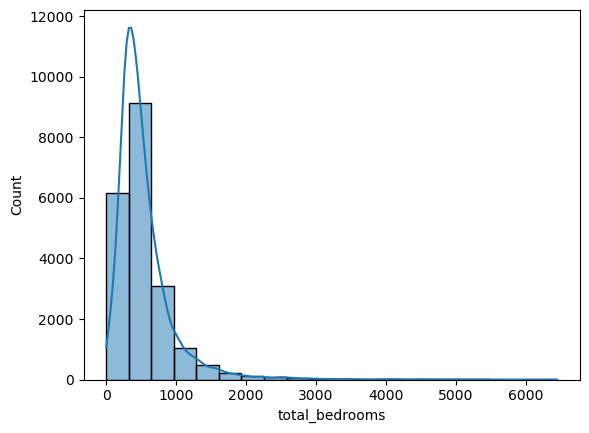

In [9]:
sns.histplot( df_copy['total_bedrooms'], kde=True, bins=20)

In [10]:
df_copy['total_bedrooms'] = df_copy['total_bedrooms'].fillna(df_copy['total_bedrooms'].mode()[0])

In [11]:
df_copy.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [12]:
# Encoding
df_copy.dtypes

longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

In [13]:
df_copy['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [14]:
from sklearn.preprocessing import OneHotEncoder

In [15]:
# ocean_proximity
encoder = OneHotEncoder()
sparx_matrics = encoder.fit_transform(df_copy[['ocean_proximity']]).toarray()
new_df = pd.DataFrame(
    sparx_matrics,
    columns=encoder.get_feature_names_out()
)

In [16]:
df_copy = pd.concat([df_copy, new_df], axis=1)

In [17]:
df_copy.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0.0,0.0,0.0,1.0,0.0


In [18]:
df_copy.drop(columns='ocean_proximity', axis=1, inplace=True)

In [19]:
df_copy.dtypes

longitude                     float64
latitude                      float64
housing_median_age            float64
total_rooms                   float64
total_bedrooms                float64
population                    float64
households                    float64
median_income                 float64
median_house_value            float64
ocean_proximity_<1H OCEAN     float64
ocean_proximity_INLAND        float64
ocean_proximity_ISLAND        float64
ocean_proximity_NEAR BAY      float64
ocean_proximity_NEAR OCEAN    float64
dtype: object

In [20]:
df_copy.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0


<Axes: xlabel='median_house_value', ylabel='Count'>

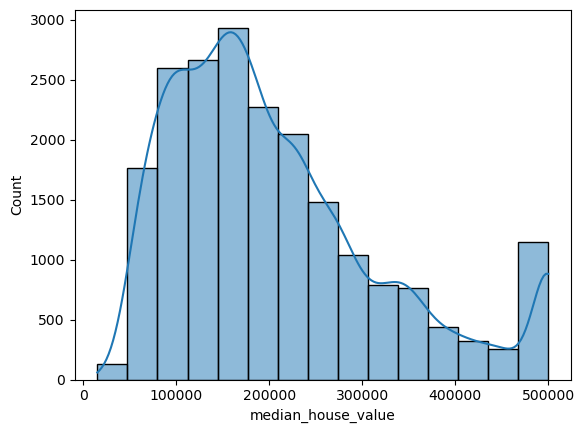

In [21]:
sns.histplot(df_copy['median_house_value'], kde=True, bins=15)

In [22]:
corr_matrix = df[[x for x in df.columns if x != 'ocean_proximity']].corr()

<Axes: >

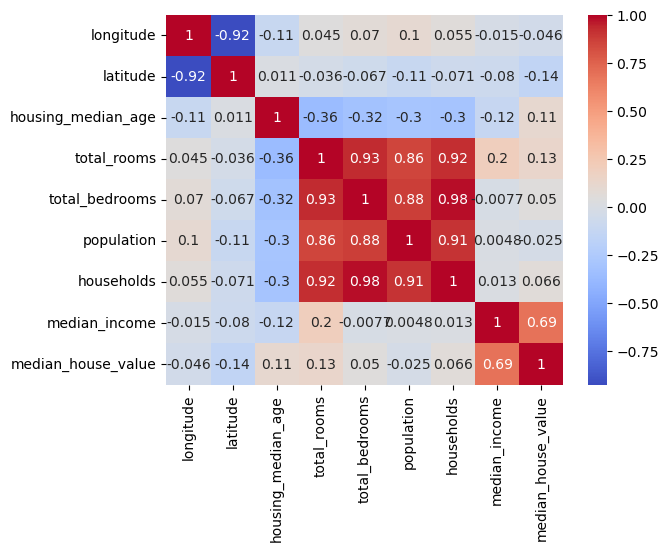

In [23]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

The upper plot indicate that - total_rooms, total_bedrooms, population, households are highly correlated to each other

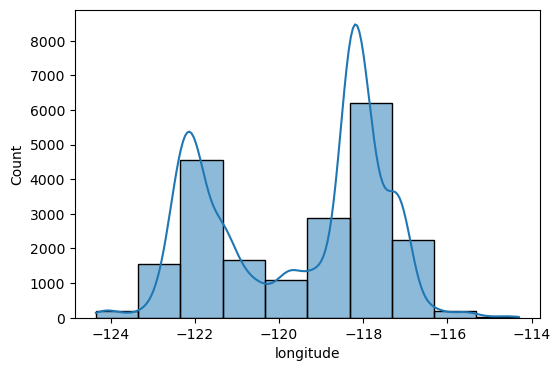

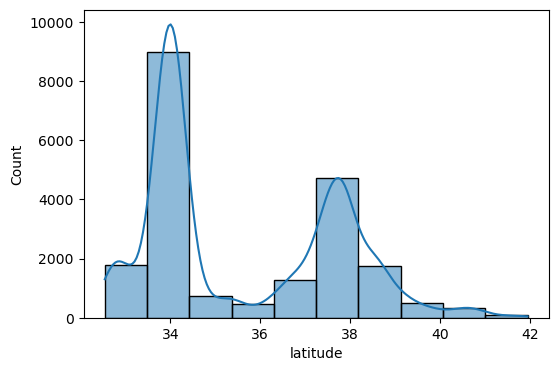

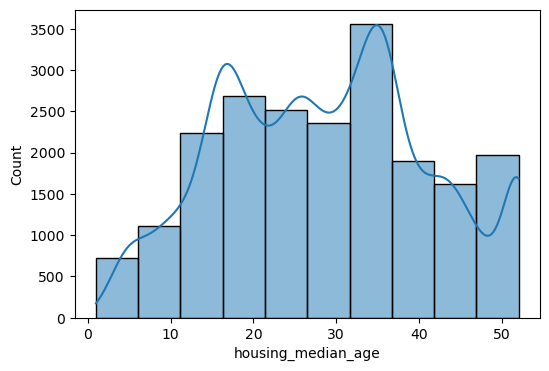

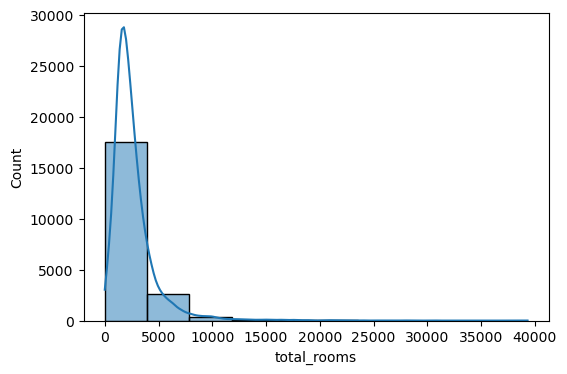

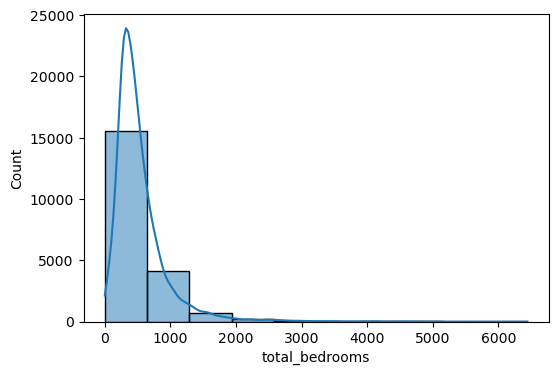

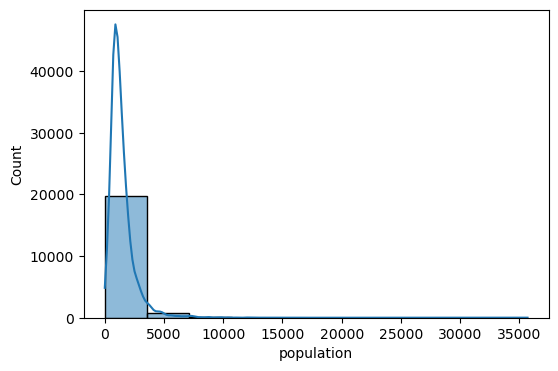

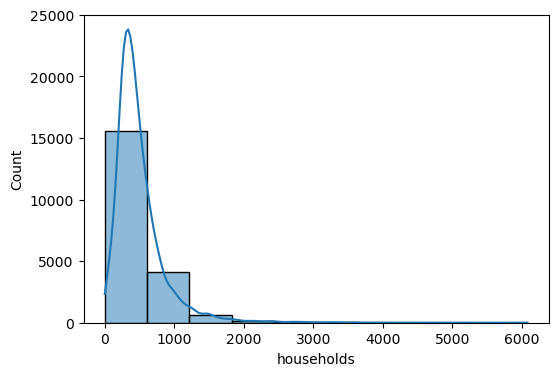

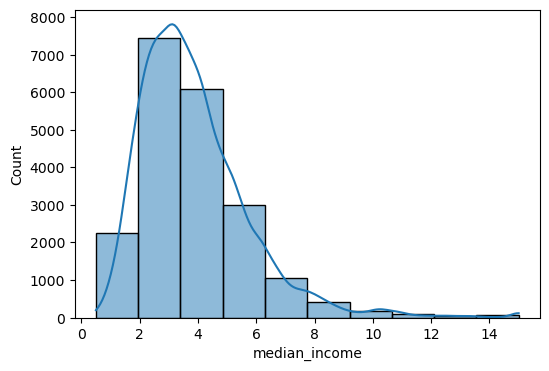

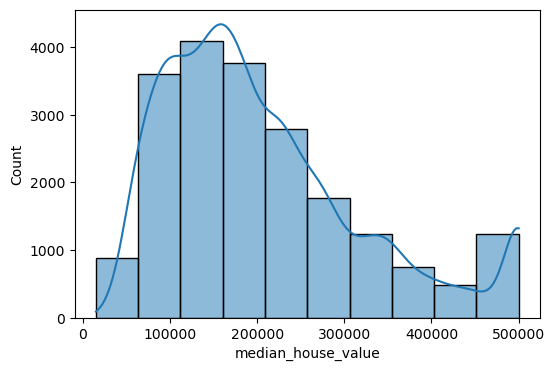

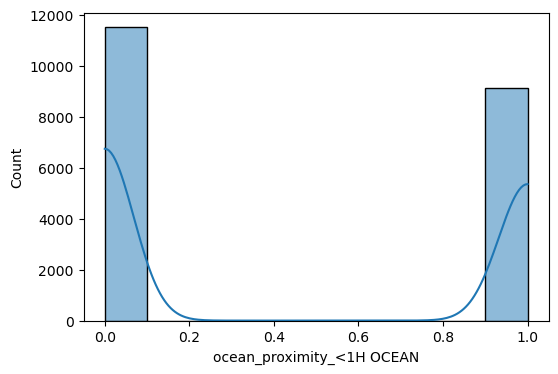

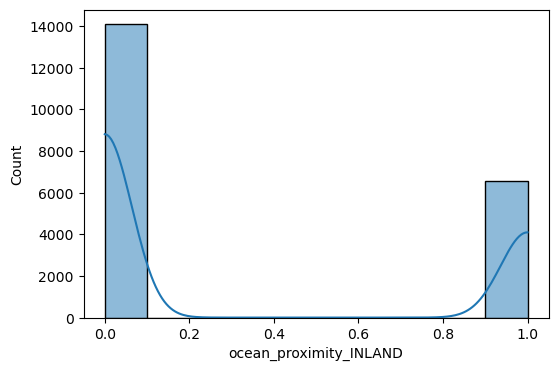

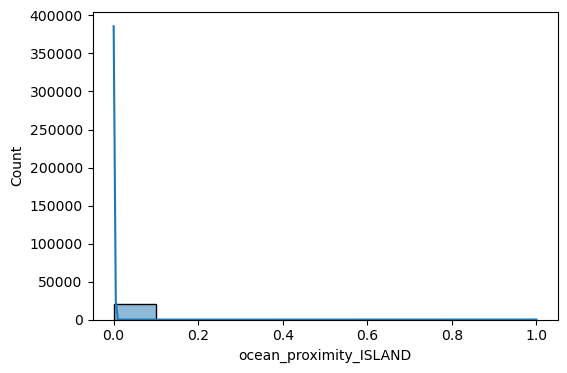

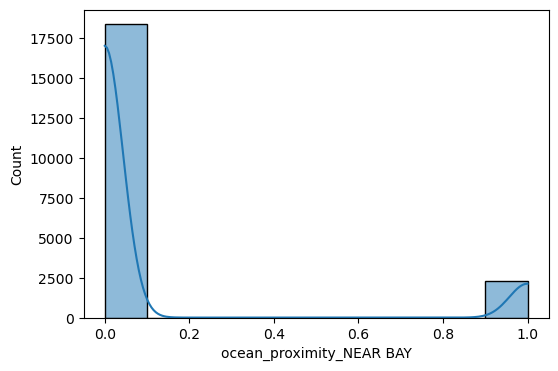

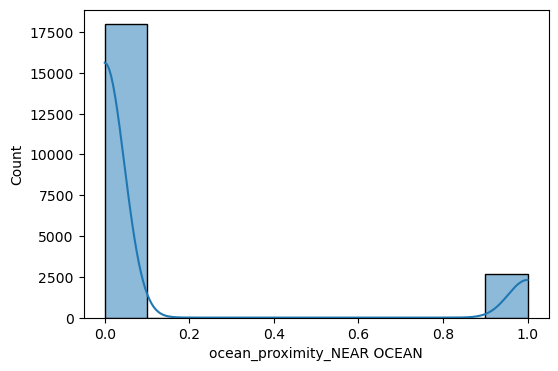

In [24]:
for feature in df_copy.columns:
    plt.figure(figsize=[6,4])
    sns.histplot(data=df_copy, x=feature, kde=True, bins=10)
    plt.show()

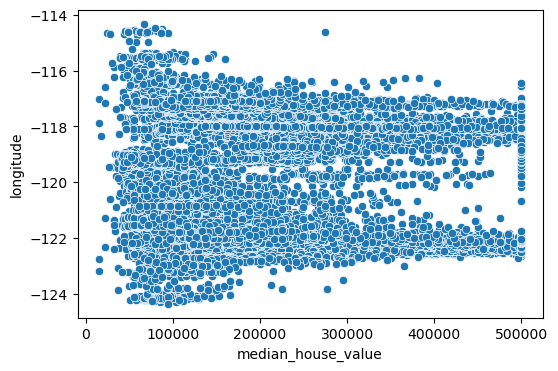

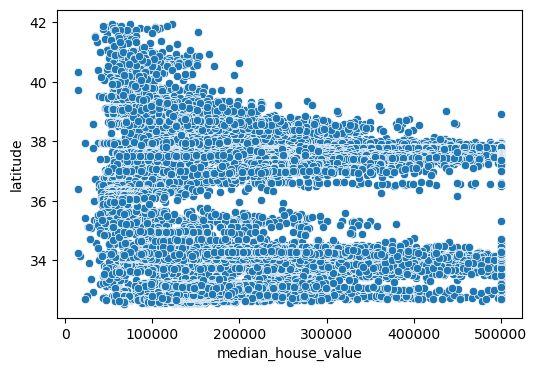

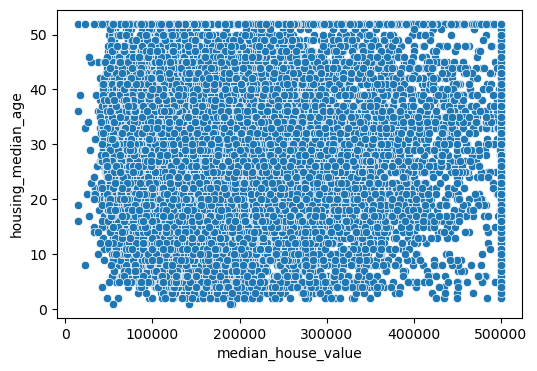

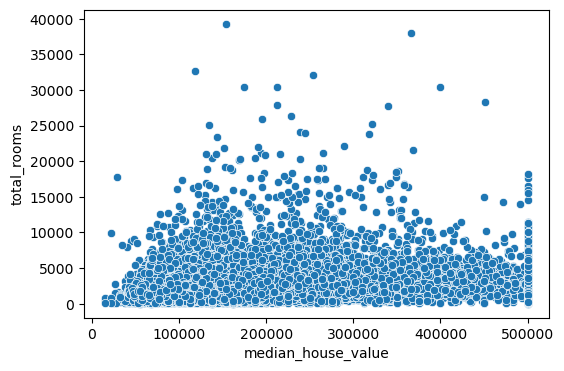

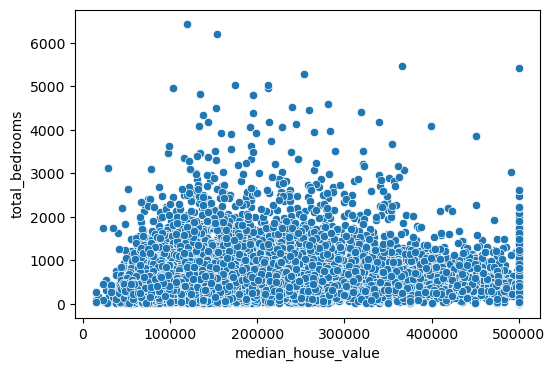

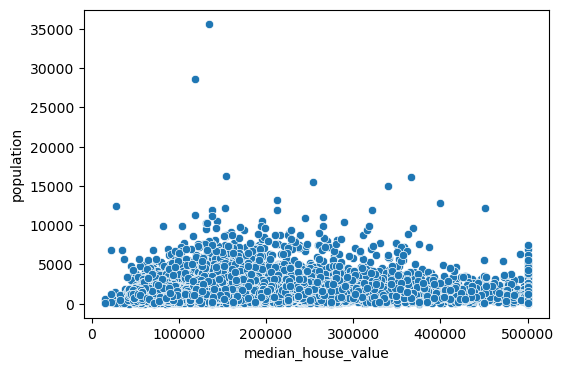

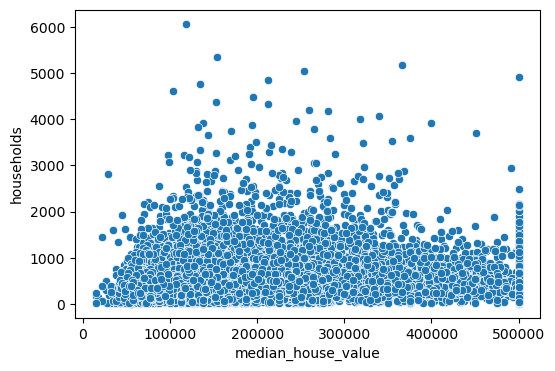

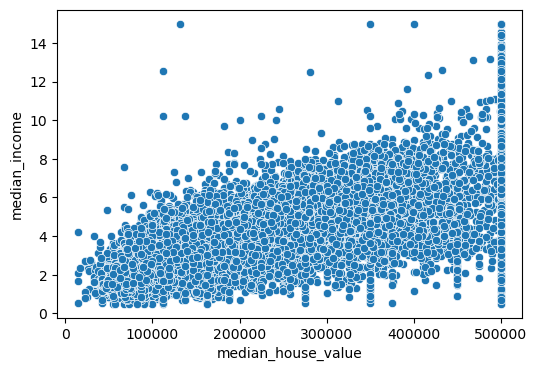

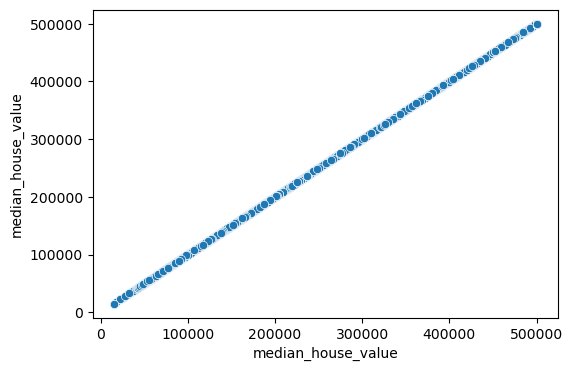

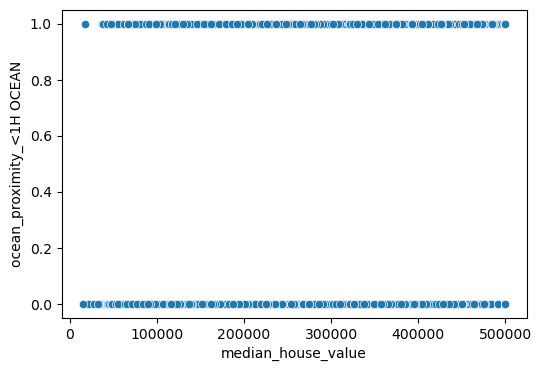

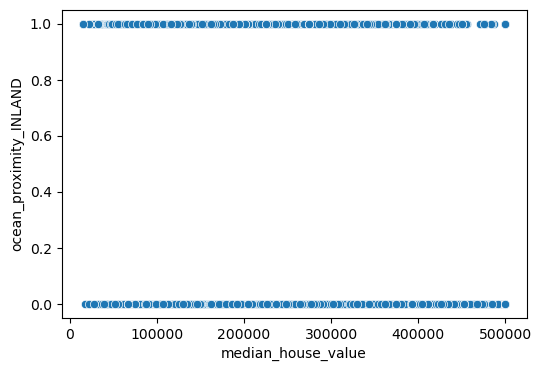

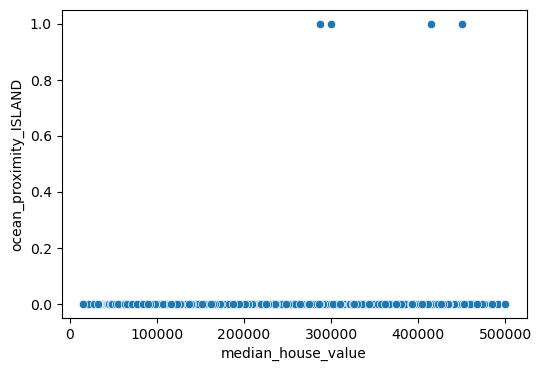

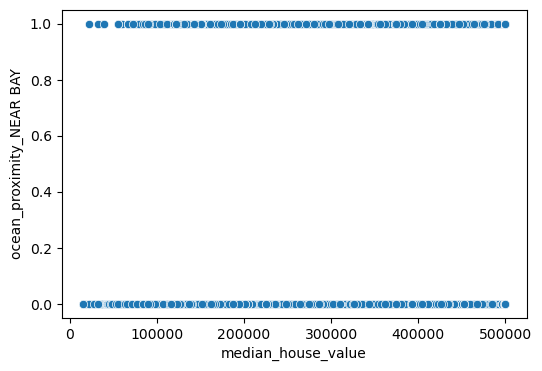

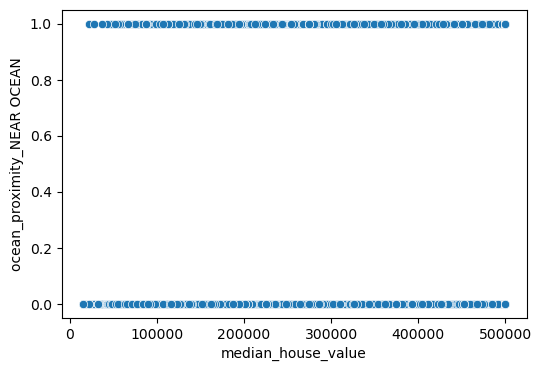

In [25]:
for feature in df_copy.columns:
    plt.figure(figsize=[6,4])
    sns.scatterplot(data=df_copy, y=feature, x='median_house_value')
    plt.show()

In [26]:
# Performing Train Test Split ---
from sklearn.model_selection import train_test_split

In [27]:
x = df_copy[[x for x in df_copy.columns if x != 'median_house_value']]
y = df['median_house_value']

In [28]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42
)

In [29]:
x_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
7061,-118.02,33.93,35.0,2400.0,398.0,1218.0,408.0,4.1312,1.0,0.0,0.0,0.0,0.0
14689,-117.09,32.79,20.0,2183.0,534.0,999.0,496.0,2.8631,0.0,0.0,0.0,0.0,1.0
17323,-120.14,34.59,24.0,1601.0,282.0,731.0,285.0,4.2026,0.0,0.0,0.0,0.0,1.0
10056,-121.00,39.26,14.0,810.0,151.0,302.0,138.0,3.1094,0.0,1.0,0.0,0.0,0.0
15750,-122.45,37.77,52.0,3188.0,708.0,1526.0,664.0,3.3068,0.0,0.0,0.0,1.0,0.0


In [30]:
# Standardization --
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()

In [32]:
x_train = scaler.fit_transform(x_train)

In [33]:
len(x_train)

14448

In [34]:
x_test = scaler.transform(x_test)

In [35]:
len(x_test)

6192

In [36]:
# Linear model training --
from sklearn.linear_model import LinearRegression

In [37]:
reggression = LinearRegression()

In [38]:
reggression.fit(x_train, y_train)

LinearRegression()

In [39]:
reggression.coef_

array([-53080.22484228, -53211.37198001,  13949.87818887, -12701.71831577,
        44378.88674127, -42559.67778653,  16172.44726364,  74802.55919045,
         6754.07079936, -12812.06710046,   2486.89080696,   2375.89794307,
         5533.32874087])

In [40]:
reggression.intercept_

np.float64(206923.96089424155)

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [42]:
mae = mean_absolute_error(y_test, reggression.predict(x_test))
mse = mean_squared_error(y_test, reggression.predict(x_test))
print('MSE - ', mse)
print('mae - ', mae)
print('RMSE - ', np.sqrt(mse))

MSE -  4752762827.792927
mae -  50131.96614863764
RMSE -  68940.28450617916


In [43]:
from sklearn.metrics import r2_score

In [44]:
score = r2_score(y_test, reggression.predict(x_test))

In [45]:
score

0.6378958022312156

In [46]:
df_copy['median_house_value'].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64